In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('trump_tweets_dataset.csv')
df.tail()

,id,date,platform,handle,text,favorite_count,repost_count,quote_flag,repost_flag,deleted_flag,word_count,hashtags,urls,user_mentions,media_count,media_urls,post_url,in_reply_to
90549,1773561338,2009-05-12T10:07:28-04:00,Twitter,realDonaldTrump,"""My persona will never be that of a wallflower...",1904,1345,False,False,False,21,NaN,NaN,NaN,0,NaN,https://x.com/realdonaldtrump/status/1773561338,NaN
90550,1741160716,2009-05-08T16:40:15-04:00,Twitter,realDonaldTrump,New Blog Post: Celebrity Apprentice Finale and...,24,11,False,False,False,13,NaN,http://www.trumpuniversity.com/blog/post/2009/...,NaN,0,NaN,https://x.com/realdonaldtrump/status/1741160716,NaN
90551,1737479987,2009-05-08T09:38:08-04:00,Twitter,realDonaldTrump,Donald Trump reads Top Ten Financial Tips on L...,33,15,False,False,False,17,NaN,https://www.youtube.com/watch?v=hmMkZD4VcNQ&fe...,NaN,0,NaN,https://x.com/realdonaldtrump/status/1737479987,NaN
90552,1701461182,2009-05-04T21:00:10-04:00,Twitter,realDonaldTrump,Donald Trump will be appearing on The View tom...,259,34,False,False,False,22,NaN,NaN,NaN,0,NaN,https://x.com/realdonaldtrump/status/1701461182,NaN
90553,1698308935,2009-05-04T14:54:25-04:00,Twitter,realDonaldTrump,Be sure to tune in and watch Donald Trump on L...,936,512,False,False,False,23,NaN,NaN,NaN,0,NaN,https://x.com/realdonaldtrump/status/1698308935,NaN


In [3]:
df['date'] = pd.to_datetime(df['date'], utc=True)
df['year'] = df.date.dt.year

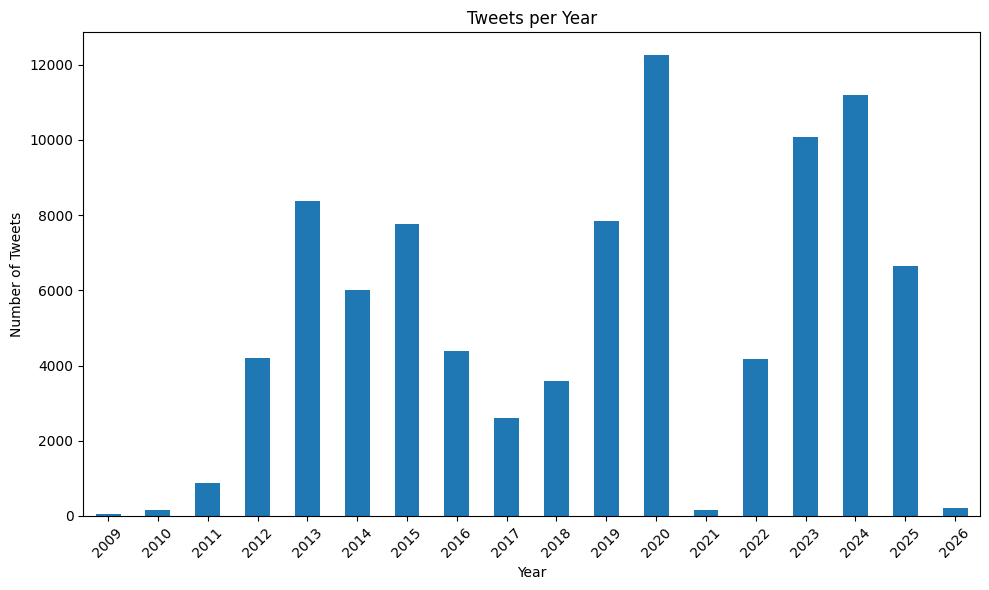

In [4]:
#tweets per year
tweets_per_year = df['year'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
tweets_per_year.plot(kind='bar')
plt.xlabel('Year')
plt.ylabel('Number of Tweets')
plt.title('Tweets per Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
unique_tweets = df['text'].nunique()  
print(f"Unique tweets: {unique_tweets}")

print(f"Total tweets: {len(df)}")
print(f"Unique tweets: {unique_tweets}")
print(f"Duplicates: {len(df) - unique_tweets}")

Unique tweets: 82130
Total tweets: 90554
Unique tweets: 82130
Duplicates: 8424


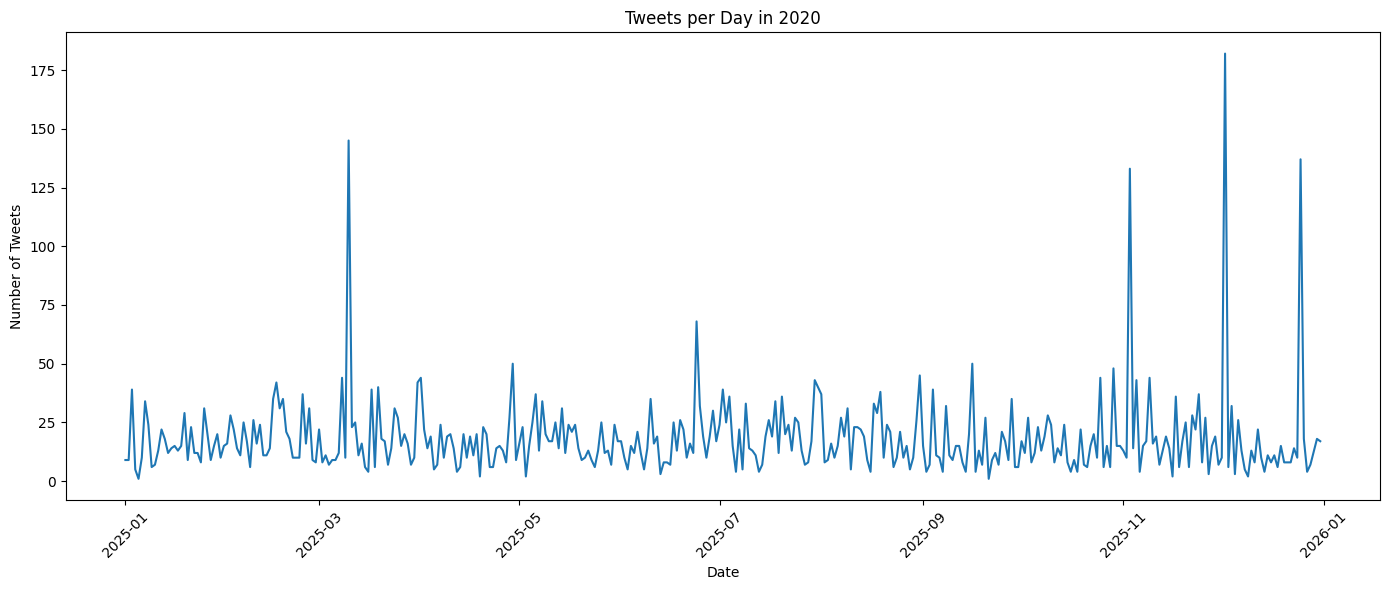

In [6]:
#tweets per day
df['day'] = df['date'].dt.date

year_to_plot = 2025
df_year = df[df['year'] == year_to_plot].copy()

tweets_per_day = df_year['day'].value_counts().sort_index()

plt.figure(figsize=(14, 6))
tweets_per_day.plot(kind='line')
plt.xlabel('Date')
plt.ylabel('Number of Tweets')
plt.title(f'Tweets per Day in 2020')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
df_year.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6644 entries, 211 to 6854
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   id              6644 non-null   int64              
 1   date            6644 non-null   datetime64[ns, UTC]
 2   platform        6644 non-null   object             
 3   handle          6644 non-null   object             
 4   text            6644 non-null   object             
 5   favorite_count  6644 non-null   int64              
 6   repost_count    6644 non-null   int64              
 7   quote_flag      6644 non-null   bool               
 8   repost_flag     6644 non-null   bool               
 9   deleted_flag    6644 non-null   bool               
 10  word_count      6644 non-null   int64              
 11  hashtags        1 non-null      object             
 12  urls            1180 non-null   object             
 13  user_mentions   440 non-null    obje

In [8]:
sample_df = df.sample(n=1000, random_state=1337)

In [9]:
nlp = spacy.load("en_core_web_sm")

In [10]:
def extract_entities(text):
    doc = nlp(text)
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    return entities

sample_df['entities'] = sample_df['text'].apply(extract_entities)

sample_df[['text', 'entities']].head(20)

,text,entities
31224,[QuickTime Video],"[(QuickTime Video, ORG)]"
8107,"Kamala Harris did NOTHING as 120,000 Armenian ...","[(Kamala Harris, PERSON), (120,000, CARDINAL),..."
37007,pic.twitter.com/FCBc2JjrCs,[]
1765,THE BIDEN FBI PLACED 274 AGENTS INTO THE CROWD...,"[(THE BIDEN FBI, ORG), (274, CARDINAL), (JANUA..."
24594,Pastor Robert Jeffress: “He is going to be the...,"[(Robert Jeffress, PERSON), (GOP, ORG), (the U..."
39679,The Radical Left Democrats new theme is “Defun...,"[(Democrats, NORP), (Defund the Police, WORK_O..."
79309,"@AlfiraAzzahra Great picture, say hello!",[]
70929,"""@HOVG: @robcesternino Johnny Damon talks @App...","[(Johnny Damon, PERSON), (#, CARDINAL)]"
28823,RT @realDonaldTrump Joe Biden said he is runni...,"[(Joe Biden, PERSON), (Hunter, PERSON), (Trump..."
52110,RT @club4growth: WE AGREE! The time is now! 👉 ...,"[(America, GPE)]"


In [11]:
sample_df.loc[28823].text

'RT @realDonaldTrump Joe Biden said he is running for President, so why isn’t he appointing a Special Counsel to look into the criminal actions of him and his son, Hunter? There has never been anything like it in the history of our Country, and amazingly, it is perfectly documented for all to see. Maybe Trump Hater Jack Smith, who should never be allowed to work on anything having to do with me because of his and his family’s anger, hatred, and bias, should be looking into the Biden Crime Family instead? Great idea!'

In [12]:
sample_df.loc[28823].entities

[('Joe Biden', 'PERSON'),
 ('Hunter', 'PERSON'),
 ('Trump Hater', 'PERSON'),
 ('Jack Smith', 'PERSON'),
 ('the Biden Crime Family', 'ORG')]

In [13]:
nicknames = pd.read_csv('trump_nicknames.csv')
nicknames.head()

,nickname,person
0,Sloppy Steve,Steve Bannon
1,AOCof Tennessee,Aftyn Behn
2,Crooked Joe,Joe Biden
3,Joe Hiden,Joe Biden
4,Sleepy Joe,Joe Biden


In [14]:
nicknames

,nickname,person
0,Sloppy Steve,Steve Bannon
1,AOCof Tennessee,Aftyn Behn
2,Crooked Joe,Joe Biden
3,Joe Hiden,Joe Biden
4,Sleepy Joe,Joe Biden
...,...,...
176,Kung Flu,SARS-CoV-2
177,Chinese Virus,SARS-CoV-2
178,China virus,SARS-CoV-2
179,ObamaCare,Medicare


In [15]:
trump_nickname_map = dict(zip(
    nicknames['nickname'].str.lower().str.strip(),
    nicknames['person'].str.strip()
))

  'sloppy steve' -> 'Steve Bannon'
  'aocof tennessee' -> 'Aftyn Behn'
  'crooked joe' -> 'Joe Biden'
  'joe hiden' -> 'Joe Biden'
  'sleepy joe' -> 'Joe Biden'
  'slow joe' -> 'Joe Biden'
  'biden' -> 'Joe Biden'
  'crooked joe biden' -> 'Joe Biden'
  'autopen' -> 'Joe Biden'
  'mini mike' -> 'Michael Bloomberg'


In [16]:
def extract_and_normalize_entities(text):
    doc = nlp(text)
    entities = []
    
    for ent in doc.ents:
        entity_text = ent.text.strip()
 
        if '@' in entity_text:
            continue

        if entity_text.startswith('RT') or 'RT @' in entity_text:
            continue

        
        false_positives = [
            'maga', 'hoax', 'witch hunt', 'djt', 'fake news',
            'usa', 'fbi', 'gop', 'cnn', 'rsbn', 'quicktime video'
        ]
        if entity_text.lower() in false_positives:
            continue
        
        #self-references
        trump_refs = ['trump', 'donald trump', 'donald j. trump', 'donald j trump']
        if entity_text.lower() in trump_refs:
            continue
        
        if len(entity_text) <= 2:
            continue

        text_clean = entity_text.lower().strip()

        if text_clean in trump_nickname_map:
            normalized = trump_nickname_map[text_clean]
        else:
            normalized = entity_text
            prefixes = ['crooked', 'sleepy', 'lyin', 'lying', 'crazy', 
                       'little', 'mini', 'low energy', 'nervous', 'shifty']
            
            for prefix in prefixes:
                if text_clean.startswith(prefix + ' '):
                    name_part = text_clean.replace(prefix + ' ', '').strip()
                    if name_part in trump_nickname_map:
                        normalized = trump_nickname_map[name_part]
                        break
            
            name_expansions = {
                'obama': 'Barack Obama',
                'biden': 'Joe Biden',
                'hillary': 'Hillary Clinton',
                'bernie': 'Bernie Sanders',
                'pelosi': 'Nancy Pelosi',
                'schumer': 'Chuck Schumer',
                'comey': 'James Comey',
                'mueller': 'Robert Mueller',
                'flynn': 'Michael Flynn',
                'pence': 'Mike Pence',
                'cruz': 'Ted Cruz',
                'rubio': 'Marco Rubio',
                'rivlin': 'Reuven Rivlin'
            }
            
            if text_clean in name_expansions:
                normalized = name_expansions[text_clean]
        
        entities.append({
            'original': entity_text,
            'normalized': normalized,
            'type': ent.label_
        })
    
    return entities



In [17]:
sample_df = df.sample(n=1000, random_state=42).copy()
sample_df['entities'] = sample_df['text'].apply(extract_and_normalize_entities)

entity_rows = []
for idx, row in sample_df.iterrows():
    for entity in row['entities']:
        entity_rows.append({
            'tweet_id': idx,
            'entity_original': entity['original'],
            'entity_normalized': entity['normalized'],
            'entity_type': entity['type']
        })

entities_sample_df = pd.DataFrame(entity_rows)

entities_sample_df['entity_normalized'].value_counts().head(20)


Extracted 1946 entities

=== TOP 20 PEOPLE (CLEANED) ===
entity_normalized
Joe Biden            28
America              24
Democrats            24
Republicans          21
China                19
U.S.                 19
today                18
Barack Obama         16
American             16
the United States    14
Russia               13
Republican           13
Hillary Clinton      13
Dems                 11
Congress             11
Democrat             10
tomorrow             10
Americans            10
first                10
Washington            9
Name: count, dtype: int64


In [18]:
entities_sample_df[entities_sample_df['entity_type']=='PERSON']

,tweet_id,entity_original,entity_normalized,entity_type
3,6662,Mark Levin,Mark Levin,PERSON
10,9985,Kamala Harris,Kamala Harris,PERSON
13,33538,Dan,Dan,PERSON
16,63422,Cruz,Ted Cruz,PERSON
23,79116,Obama,Barack Obama,PERSON
...,...,...,...,...
1927,17635,Crooked Joe Biden,Joe Biden,PERSON
1928,17723,Crooked Joe Biden,Joe Biden,PERSON
1937,50326,Reuven Rivlin,Reuven Rivlin,PERSON
1939,50326,Nechama Rivlin,Nechama Rivlin,PERSON


In [20]:
#vader sentiment
vader = SentimentIntensityAnalyzer()


def get_sentiment(text):
    scores = vader.polarity_scores(text)
    return scores
    
df['text'] = df['text'].fillna('').astype(str)
df['sentiment'] = df['text'].apply(get_sentiment)

df['sentiment_compound'] = df['sentiment'].apply(lambda x: x['compound'])
df['sentiment_positive'] = df['sentiment'].apply(lambda x: x['pos'])
df['sentiment_negative'] = df['sentiment'].apply(lambda x: x['neg'])
df['sentiment_neutral'] = df['sentiment'].apply(lambda x: x['neu'])

def categorize_sentiment(compound_score):
    if compound_score >= 0.05:
        return 'Positive'
    elif compound_score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_category'] = df['sentiment_compound'].apply(categorize_sentiment)


df[['text', 'sentiment_compound', 'sentiment_category']].head(10)

                                                text  sentiment_compound  \
0  Arrest them all. They are criminals!!! \nForei...             -0.7891   
1  When a vehicle is coming at you and is being u...              0.1280   
2  It was a Great Honor to speak with the Preside...              0.8316   
3  I have just been informed that Venezuela is go...              0.9590   
4  After long and difficult negotiations with Sen...              0.9273   
5  I have been informed by the Department of War ...             -0.9047   
6  I have just viewed the clip of the event which...             -0.9273   
7  All United State Defense Contractors, and the ...              0.9761   
8  For a very long time, buying and owning a home...             -0.1531   
9  In honor of the late, GREAT, Congressman Doug ...              0.9560   

  sentiment_category  
0           Negative  
1           Positive  
2           Positive  
3           Positive  
4           Positive  
5           Negative  
6 

In [21]:
df['entities'] = df['text'].apply(extract_and_normalize_entities)

entity_rows = []
for idx, row in df.iterrows():
    for entity in row['entities']:
        entity_rows.append({
            'tweet_id': idx,
            'entity_original': entity['original'],
            'entity_normalized': entity['normalized'],
            'entity_type': entity['type']
        })

entities_df = pd.DataFrame(entity_rows)

In [32]:
entities_sentiment_df = entities_df.merge(
    df[['date','sentiment_compound', 'sentiment_positive', 'sentiment_negative', 
        'sentiment_neutral', 'sentiment_category', 'text']],
    left_on='tweet_id',
    right_index=True,
    how='left'
)



In [33]:
entities_sentiment_df.iloc[9]

tweet_id                                                              2
entity_original                                         the White House
entity_normalized                                       the White House
entity_type                                                         ORG
date                                          2026-01-07 23:53:08+00:00
sentiment_compound                                               0.8316
sentiment_positive                                                0.129
sentiment_negative                                                0.034
sentiment_neutral                                                 0.837
sentiment_category                                             Positive
text                  It was a Great Honor to speak with the Preside...
Name: 9, dtype: object

In [24]:
entities_sentiment_df.to_csv('entities_with_sentiment_dataset.csv')

In [31]:
entities_sentiment_df.columns

Index(['tweet_id', 'entity_original', 'entity_normalized', 'entity_type',
       'sentiment_compound', 'sentiment_positive', 'sentiment_negative',
       'sentiment_neutral', 'sentiment_category', 'text'],
      dtype='object')

In [40]:
#adding dates 
entities_sentiment_df['date'] = pd.to_datetime(entities_sentiment_df['date']).dt.date

entity_sentiment_timeline = entities_sentiment_df.groupby(
    ['entity_normalized', 'date']
).agg({
    'sentiment_compound': 'mean',  
    'sentiment_positive': 'mean',
    'sentiment_negative': 'mean',
    'sentiment_neutral': 'mean',
    'tweet_id': 'count'  
}).reset_index()

entity_sentiment_timeline.columns = [
    'entity', 'date', 'avg_sentiment_compound', 'avg_sentiment_positive',
    'avg_sentiment_negative', 'avg_sentiment_neutral', 'mention_count'
]

In [46]:
top_people = entities_sentiment_df[
    entities_sentiment_df['entity_type'] == 'PERSON'
]['entity_normalized'].value_counts().head(15)


top_people

top_people_list = top_people.index.tolist()

key_people_timeline = entity_sentiment_timeline[
    entity_sentiment_timeline['entity'].isin(top_people_list)
].sort_values(['entity', 'date'])

key_people_timeline.head(20)

,entity,date,avg_sentiment_compound,avg_sentiment_positive,avg_sentiment_negative,avg_sentiment_neutral,mention_count
21961,Barack Obama,2010-11-22,0.92740,0.382,0.0000,0.6180,1
21962,Barack Obama,2011-05-02,0.70890,0.266,0.0000,0.7340,1
21963,Barack Obama,2011-07-06,-0.76030,0.000,0.2840,0.7160,1
21964,Barack Obama,2011-07-08,-0.66960,0.000,0.2820,0.7180,1
21965,Barack Obama,2011-07-20,0.00000,0.000,0.0000,1.0000,1
21966,Barack Obama,2011-07-26,-0.61240,0.000,0.3570,0.6430,1
21967,Barack Obama,2011-07-28,-0.59940,0.000,0.2050,0.7950,1
21968,Barack Obama,2011-07-29,-0.54230,0.062,0.1820,0.7560,1
21969,Barack Obama,2011-08-03,0.51060,0.180,0.0000,0.8200,1
21970,Barack Obama,2011-08-12,0.40190,0.257,0.1150,0.6280,1


In [48]:
#rolling windows
smoothed_data = []

for entity in top_people_list:
    entity_data = key_people_timeline[key_people_timeline['entity'] == entity].copy()
    entity_data = entity_data.sort_values('date')
    
    #getting back time for rolling windows
    entity_data['date'] = pd.to_datetime(entity_data['date'])
    
   
    entity_data['sentiment_7day_avg'] = entity_data['avg_sentiment_compound'].rolling(
        window=7, min_periods=1
    ).mean()
    
    
    entity_data['sentiment_30day_avg'] = entity_data['avg_sentiment_compound'].rolling(
        window=30, min_periods=1
    ).mean()
    
    smoothed_data.append(entity_data)

entity_sentiment_smoothed = pd.concat(smoothed_data, ignore_index=True)


entity_sentiment_smoothed[entity_sentiment_smoothed['entity'] == 'Joe Biden'].head(10)

,entity,date,avg_sentiment_compound,avg_sentiment_positive,avg_sentiment_negative,avg_sentiment_neutral,mention_count,sentiment_7day_avg,sentiment_30day_avg
0,Joe Biden,2011-09-30,-0.3400,0.000,0.1380,0.862,1,-0.340000,-0.340000
1,Joe Biden,2011-12-20,-0.0644,0.102,0.1110,0.787,2,-0.202200,-0.202200
2,Joe Biden,2011-12-21,0.4310,0.130,0.0000,0.870,1,0.008867,0.008867
3,Joe Biden,2011-12-22,0.2382,0.103,0.1050,0.793,1,0.066200,0.066200
4,Joe Biden,2012-03-29,-0.7003,0.000,0.2660,0.734,1,-0.087100,-0.087100
5,Joe Biden,2012-05-09,-0.6164,0.000,0.2180,0.782,1,-0.175317,-0.175317
6,Joe Biden,2012-10-10,0.2244,0.095,0.0000,0.905,1,-0.118214,-0.118214
7,Joe Biden,2012-10-12,0.0534,0.167,0.1805,0.653,2,-0.062014,-0.096763
8,Joe Biden,2012-10-31,-0.4767,0.000,0.1470,0.853,1,-0.120914,-0.138978
9,Joe Biden,2013-04-17,-0.6808,0.000,0.2280,0.772,1,-0.279743,-0.193160


In [49]:
entity_sentiment_timeline[entity_sentiment_timeline['entity']=='Joe Biden']

,entity,date,avg_sentiment_compound,avg_sentiment_positive,avg_sentiment_negative,avg_sentiment_neutral,mention_count
62888,Joe Biden,2011-09-30,-0.3400,0.000,0.138,0.862,1
62889,Joe Biden,2011-12-20,-0.0644,0.102,0.111,0.787,2
62890,Joe Biden,2011-12-21,0.4310,0.130,0.000,0.870,1
62891,Joe Biden,2011-12-22,0.2382,0.103,0.105,0.793,1
62892,Joe Biden,2012-03-29,-0.7003,0.000,0.266,0.734,1
...,...,...,...,...,...,...,...
63842,Joe Biden,2025-12-15,0.9571,0.142,0.048,0.810,3
63843,Joe Biden,2025-12-31,-0.9733,0.059,0.192,0.749,1
63844,Joe Biden,2026-01-02,0.5386,0.144,0.102,0.754,1
63845,Joe Biden,2026-01-06,0.9393,0.155,0.118,0.727,1


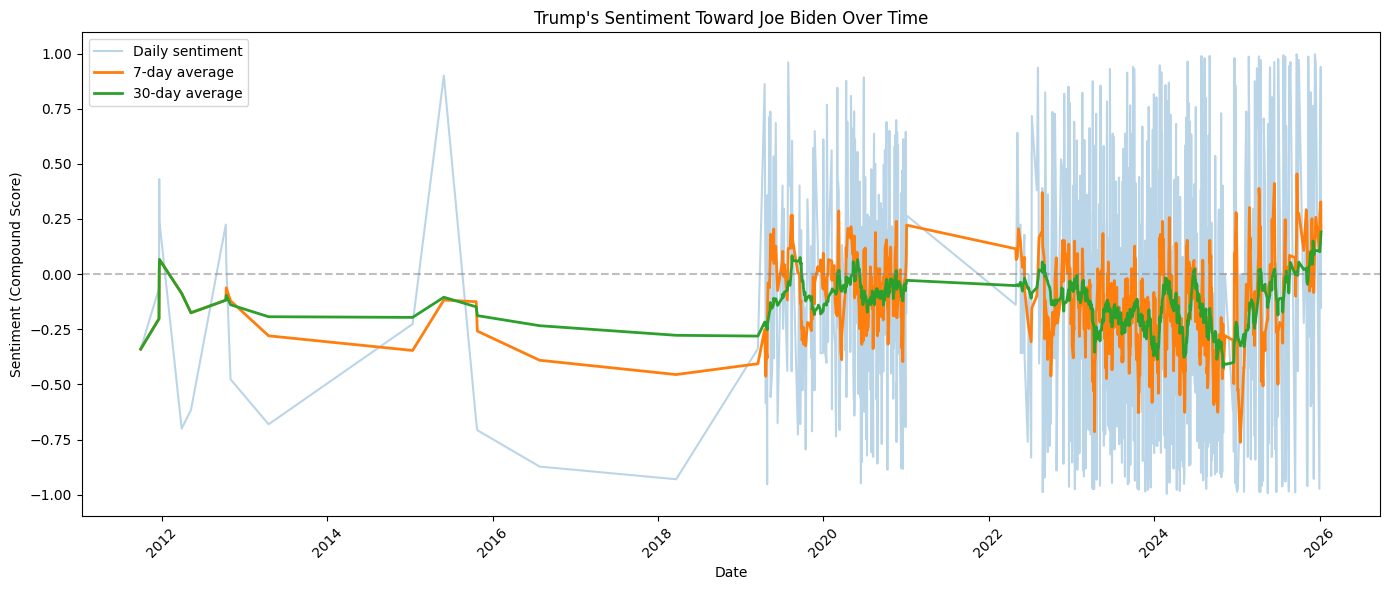

In [50]:
person = 'Joe Biden'  
person_data = entity_sentiment_smoothed[entity_sentiment_smoothed['entity'] == person]

plt.figure(figsize=(14, 6))
plt.plot(person_data['date'], person_data['avg_sentiment_compound'], 
         alpha=0.3, label='Daily sentiment')
plt.plot(person_data['date'], person_data['sentiment_7day_avg'], 
         linewidth=2, label='7-day average')
plt.plot(person_data['date'], person_data['sentiment_30day_avg'], 
         linewidth=2, label='30-day average')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.title(f"Trump's Sentiment Toward {person} Over Time")
plt.xlabel('Date')
plt.ylabel('Sentiment (Compound Score)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()